# ソフトマックス関数 — 多入力多出力の探究

ソフトマックスは他の活性化関数と違い、**入力も出力もベクトル** で、しかも**出力の各要素が他のすべての入力に依存する**(出力どうしが結合している)関数です。

$$
\mathrm{softmax}(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
\qquad (i = 1, 2, \dots, K)
$$

このノートブックでは 3 クラスを題材に、ソフトマックスの多入力多出力性を 6 つの視点で見ていきます。

| 節 | 視点 |
|---|---|
| ① | 3 入力 → 3 出力の基本的な変換 |
| ② | 1 つの入力を変化させたとき、3 出力すべてが連動する様子 |
| ③ | 2 次元入力空間での決定領域 (ヒートマップ) |
| ④ | 温度パラメータ T による分布の鋭さの制御 |
| ⑤ | ヤコビ行列 $\partial p_i / \partial z_j$ の構造 |
| ⑥ | クロスエントロピーと組み合わせたときの勾配の美しい簡約 |

### 多入力多出力の代表例

- **多クラス分類**: MNIST(10 クラス), ImageNet(1000 クラス), Iris(3 クラス)など
- **Transformer の Attention**: クエリ 1 個に対し N 個のキーへの重み分布を生成
- **強化学習のポリシーネット**: 状態 → 行動 K 個の選択確率
- **混合モデルのゲーティング**: K 個のエキスパートの寄与率


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib  # 日本語フォント対応

plt.rcParams['figure.dpi'] = 100
np.set_printoptions(precision=4, suppress=True)


def softmax(z, axis=-1):
    # 数値的に安定なソフトマックス: z の最大値を引いてから exp を取る
    z = np.asarray(z, dtype=float)
    z_max = np.max(z, axis=axis, keepdims=True)
    e = np.exp(z - z_max)
    return e / np.sum(e, axis=axis, keepdims=True)


# 動作確認
test_z = np.array([2.0, 1.0, 0.1])
print('入力 z =', test_z)
print('softmax(z) =', softmax(test_z))
print('合計        =', softmax(test_z).sum())


入力 z = [2.  1.  0.1]
softmax(z) = [0.659  0.2424 0.0986]
合計        = 1.0


## ① 基本: 3 入力 → 3 出力

3 つの実数値(ロジット $z_1, z_2, z_3$)を入力すると、合計 1 になる確率 $p_1, p_2, p_3$ が出力される。下の図で **入力の大小関係が確率にどう反映されるか** を確認する。


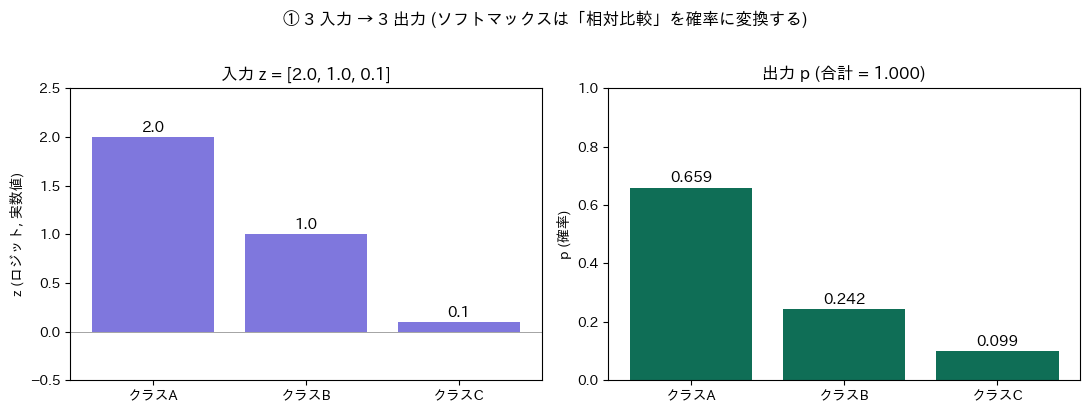

z = [2.  1.  0.1]
p = [0.659  0.2424 0.0986]
p の合計 = 1.000000


In [3]:
labels = ['クラスA', 'クラスB', 'クラスC']
z = np.array([2.0, 1.0, 0.1])
p = softmax(z)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# 入力(ロジット)
bars1 = ax1.bar(labels, z, color='#7F77DD')
for i, v in enumerate(z):
    ax1.text(i, v + 0.05, f'{v:.1f}', ha='center', fontsize=11)
ax1.set_ylabel('z (ロジット, 実数値)')
ax1.set_title(f'入力 z = {z.tolist()}')
ax1.axhline(0, color='gray', linewidth=0.5)
ax1.set_ylim(-0.5, 2.5)

# 出力(確率)
bars2 = ax2.bar(labels, p, color='#0F6E56')
for i, v in enumerate(p):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11)
ax2.set_ylabel('p (確率)')
ax2.set_title(f'出力 p (合計 = {p.sum():.3f})')
ax2.set_ylim(0, 1)

fig.suptitle('① 3 入力 → 3 出力 (ソフトマックスは「相対比較」を確率に変換する)', y=1.02)
plt.tight_layout()
plt.show()

print(f'z = {z}')
print(f'p = {p}')
print(f'p の合計 = {p.sum():.6f}')


## ② 1 入力を変化させたとき、3 出力すべてが連動する

これがソフトマックスの「**多入力多出力**」たる所以。
$z_1$ を −5 から +5 まで動かすと、$p_1$ だけでなく $p_2$, $p_3$ も同時に変化する($z_2, z_3$ は固定)。

「**$z_1$ が大きくなるほど $p_1$ が他から確率を奪う**」というゼロサム的な振る舞いが見える。


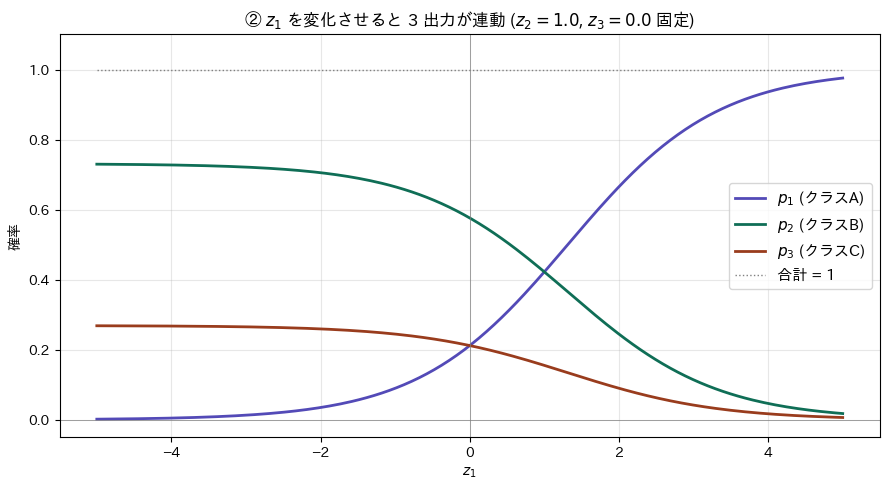

In [3]:
z1_range = np.linspace(-5, 5, 200)
z2_fixed, z3_fixed = 1.0, 0.0

# 各 z1 についてソフトマックスを計算してまとめる
z_all = np.stack([z1_range,
                  np.full_like(z1_range, z2_fixed),
                  np.full_like(z1_range, z3_fixed)], axis=-1)  # (200, 3)
p_all = softmax(z_all, axis=-1)  # (200, 3)
p1, p2, p3 = p_all[:, 0], p_all[:, 1], p_all[:, 2]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(z1_range, p1, label=r'$p_1$ (クラスA)', linewidth=2, color='#534AB7')
ax.plot(z1_range, p2, label=r'$p_2$ (クラスB)', linewidth=2, color='#0F6E56')
ax.plot(z1_range, p3, label=r'$p_3$ (クラスC)', linewidth=2, color='#993C1D')
# 合計が常に 1
ax.plot(z1_range, p1 + p2 + p3, label='合計 = 1', linewidth=1, color='gray', linestyle=':')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel(r'$z_1$')
ax.set_ylabel('確率')
ax.set_title(f'② $z_1$ を変化させると 3 出力が連動 ($z_2={z2_fixed}$, $z_3={z3_fixed}$ 固定)')
ax.legend(fontsize=11, loc='center right')
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.05, 1.1)
plt.tight_layout()
plt.show()


## ③ 2 次元入力空間での決定領域

$z_1$ と $z_2$ の 2 軸を動かし、$z_3 = 0$ を固定して、各点での 3 つの確率と「最も確率が高いクラス」(argmax)を可視化する。

これは **多クラス分類器の決定境界** がそのまま見える図で、ソフトマックスがどう入力空間を分割しているかが直感的に分かる。


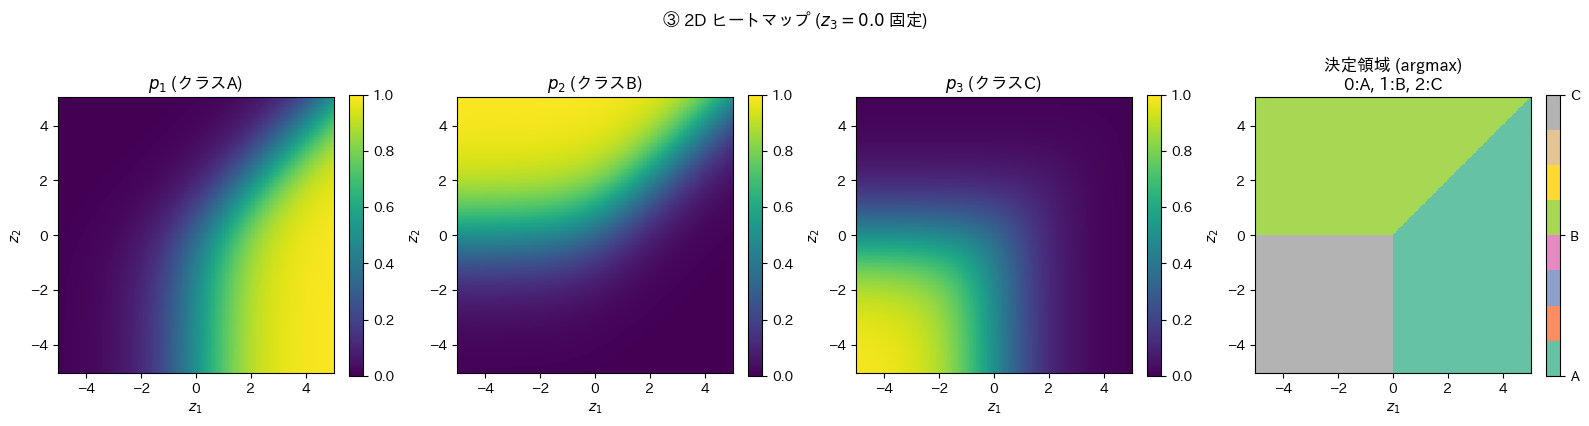

In [4]:
z1_grid = np.linspace(-5, 5, 200)
z2_grid = np.linspace(-5, 5, 200)
Z1, Z2 = np.meshgrid(z1_grid, z2_grid)
z3_fixed = 0.0

# 全格子点でソフトマックスを一気に計算
stacked = np.stack([Z1, Z2, np.full_like(Z1, z3_fixed)], axis=-1)  # (200, 200, 3)
probs = softmax(stacked, axis=-1)
P1, P2, P3 = probs[..., 0], probs[..., 1], probs[..., 2]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, P, title in zip(axes[:3], [P1, P2, P3],
                         [r'$p_1$ (クラスA)', r'$p_2$ (クラスB)', r'$p_3$ (クラスC)']):
    im = ax.pcolormesh(Z1, Z2, P, cmap='viridis', vmin=0, vmax=1, shading='auto')
    ax.set_xlabel(r'$z_1$'); ax.set_ylabel(r'$z_2$')
    ax.set_title(title)
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, fraction=0.046)

# 決定領域(argmax)
argmax = np.argmax(probs, axis=-1)
im = axes[3].pcolormesh(Z1, Z2, argmax, cmap='Set2', shading='auto', vmin=0, vmax=2)
axes[3].set_xlabel(r'$z_1$'); axes[3].set_ylabel(r'$z_2$')
axes[3].set_title('決定領域 (argmax)\n0:A, 1:B, 2:C')
axes[3].set_aspect('equal')
cb = plt.colorbar(im, ax=axes[3], fraction=0.046, ticks=[0, 1, 2])
cb.set_ticklabels(['A', 'B', 'C'])

fig.suptitle(f'③ 2D ヒートマップ ($z_3={z3_fixed}$ 固定)', y=1.02)
plt.tight_layout()
plt.show()


## ④ 温度パラメータ T による分布の鋭さの制御

ソフトマックスに温度 $T$ を加えた

$$
\mathrm{softmax}_T(\mathbf{z})_i = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}
$$

は、知識蒸留 (Hinton 2015)、強化学習の方策の探索 vs 活用、Transformer の attention の鋭さ調整 など、実用で頻出。

- $T \to 0$ : argmax に近づく(最大値が確率 1)
- $T = 1$ : 通常のソフトマックス
- $T \to \infty$ : 一様分布に近づく


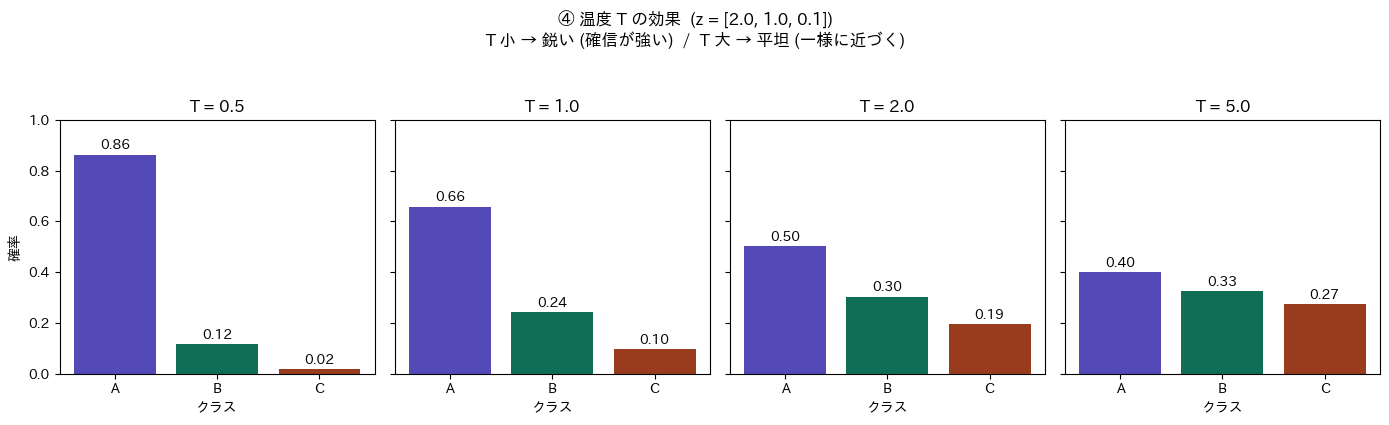

In [5]:
z = np.array([2.0, 1.0, 0.1])
temperatures = [0.5, 1.0, 2.0, 5.0]
labels = ['A', 'B', 'C']
colors = ['#534AB7', '#0F6E56', '#993C1D']

fig, axes = plt.subplots(1, len(temperatures), figsize=(14, 4), sharey=True)
for ax, T in zip(axes, temperatures):
    p = softmax(z / T)
    bars = ax.bar(labels, p, color=colors)
    for i, prob in enumerate(p):
        ax.text(i, prob + 0.02, f'{prob:.2f}', ha='center', fontsize=10)
    ax.set_title(f'T = {T}')
    ax.set_ylim(0, 1)
    ax.set_xlabel('クラス')

axes[0].set_ylabel('確率')
fig.suptitle(f'④ 温度 T の効果  (z = {z.tolist()})\n'
             'T 小 → 鋭い (確信が強い)  /  T 大 → 平坦 (一様に近づく)', y=1.05)
plt.tight_layout()
plt.show()


## ⑤ ヤコビ行列の構造

ソフトマックスの偏微分は **K × K のヤコビ行列** になる:

$$
\frac{\partial p_i}{\partial z_j} =
\begin{cases}
p_i (1 - p_i) & (i = j) \\
-\, p_i p_j & (i \neq j)
\end{cases}
\qquad\Longleftrightarrow\qquad
\mathbf{J} = \mathrm{diag}(\mathbf{p}) - \mathbf{p}\mathbf{p}^\top
$$

- **対角成分は正**: 自分のロジットを上げれば自分の確率は上がる
- **非対角は負**: 他人のロジットを上げると自分の確率は下がる
- **各行の和は 0**: 全確率の合計が 1 で固定されている制約から

これがまさに「**多入力多出力で、出力が全部つながっている**」という性質の数学的表現。


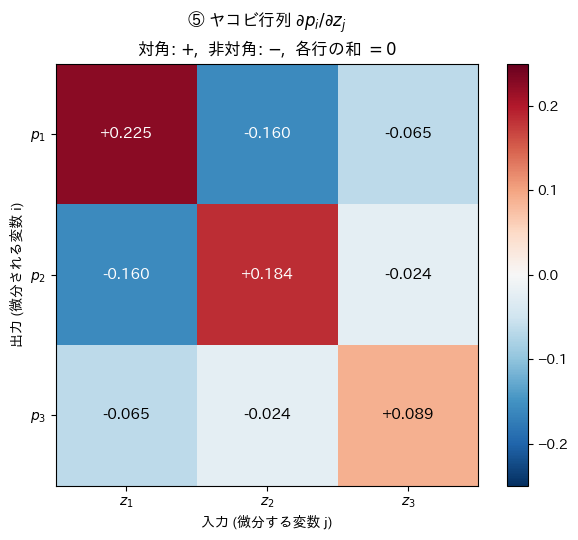

p = [0.659  0.2424 0.0986]
対角成分 p_i(1-p_i) = [0.2247 0.1837 0.0889]
各行の和(=0 になるはず): [0. 0. 0.]


In [6]:
z = np.array([2.0, 1.0, 0.1])
p = softmax(z)

# J = diag(p) - p p^T
J = np.diag(p) - np.outer(p, p)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(J, cmap='RdBu_r', vmin=-0.25, vmax=0.25)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{J[i,j]:+.3f}', ha='center', va='center',
                color='white' if abs(J[i,j]) > 0.15 else 'black', fontsize=11)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels([r'$z_1$', r'$z_2$', r'$z_3$'])
ax.set_yticks([0, 1, 2])
ax.set_yticklabels([r'$p_1$', r'$p_2$', r'$p_3$'])
ax.set_xlabel('入力 (微分する変数 j)')
ax.set_ylabel('出力 (微分される変数 i)')
ax.set_title(r'⑤ ヤコビ行列 $\partial p_i / \partial z_j$' + '\n'
             '対角: $+$,  非対角: $-$,  各行の和 $= 0$')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

print(f'p = {p}')
print(f'対角成分 p_i(1-p_i) = {np.diag(J)}')
print(f'各行の和(=0 になるはず): {J.sum(axis=1)}')


## ⑥ クロスエントロピー × ソフトマックスの「美しい簡約」

これがソフトマックスが分類タスクで標準になっている**最大の理由**。

正解を one-hot ベクトル $\mathbf{t}$ としてクロスエントロピー損失

$$
L = -\sum_i t_i \log p_i
$$

を $z$ で微分すると、ヤコビ行列との連鎖律で複雑な計算になりそうだが、実際には次のような**驚くほど簡単な形**に簡約される:

$$
\boxed{\;\frac{\partial L}{\partial z_i} = p_i - t_i\;}
$$

「予測 − 正解」というシンプルさ。これがあるおかげで誤差逆伝播が速く・安定に動く。数値微分で確認する。


入力 z      = [2.  1.  0.1]
正解 t      = [1. 0. 0.]  (クラスA が正解)
予測 p      = [0.659  0.2424 0.0986]
損失 L      = 0.417030

解析的勾配 (p - t)   = [-0.341   0.2424  0.0986]
数値微分での勾配     = [-0.341   0.2424  0.0986]
差                   = [0. 0. 0.]

→ 解析解 p - t がぴったり一致 ✓
  (クラスA の勾配が負 = z_1 を大きくすれば損失が下がる、と読める)


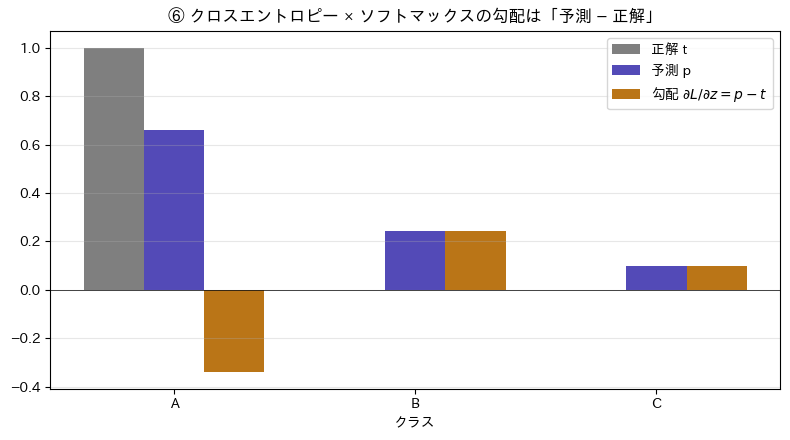

In [7]:
# 設定: 入力 z, 正解 t (クラスA が正解 → one-hot)
z = np.array([2.0, 1.0, 0.1])
t = np.array([1.0, 0.0, 0.0])

# Forward
p = softmax(z)
L = -np.sum(t * np.log(p))

# 解析的勾配: dL/dz = p - t
grad_analytical = p - t

# 数値微分で答え合わせ
eps = 1e-5
grad_numerical = np.zeros_like(z)
for i in range(len(z)):
    z_plus = z.copy(); z_plus[i] += eps
    z_minus = z.copy(); z_minus[i] -= eps
    L_plus = -np.sum(t * np.log(softmax(z_plus)))
    L_minus = -np.sum(t * np.log(softmax(z_minus)))
    grad_numerical[i] = (L_plus - L_minus) / (2 * eps)

print(f'入力 z      = {z}')
print(f'正解 t      = {t}  (クラスA が正解)')
print(f'予測 p      = {p}')
print(f'損失 L      = {L:.6f}')
print()
print(f'解析的勾配 (p - t)   = {grad_analytical}')
print(f'数値微分での勾配     = {grad_numerical}')
print(f'差                   = {np.abs(grad_analytical - grad_numerical)}')
print()
print('→ 解析解 p - t がぴったり一致 ✓')
print('  (クラスA の勾配が負 = z_1 を大きくすれば損失が下がる、と読める)')


# 可視化
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(3)
w = 0.25
ax.bar(x - w, t, width=w, label='正解 t', color='#7F7F7F')
ax.bar(x, p, width=w, label='予測 p', color='#534AB7')
ax.bar(x + w, grad_analytical, width=w, label=r'勾配 $\partial L/\partial z = p - t$',
       color='#BA7517')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(['A', 'B', 'C'])
ax.set_xlabel('クラス')
ax.set_title('⑥ クロスエントロピー × ソフトマックスの勾配は「予測 − 正解」')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


## まとめ

| 視点 | 学べたこと |
|---|---|
| ① 基本変換 | 入力の **相対** 大小が確率の大小を決める(絶対値ではなく差) |
| ② 1 入力を変化 | 出力どうしがゼロサム的に連動(片方が増えれば他方が減る) |
| ③ 2D 決定領域 | 入力空間の各点で argmax を取ると、線形分類境界が現れる |
| ④ 温度 T | 同じ入力でも T で分布の鋭さを後付けで調整可能 |
| ⑤ ヤコビ行列 | $\mathbf{J} = \mathrm{diag}(\mathbf{p}) - \mathbf{p}\mathbf{p}^\top$, 各行の和は 0 |
| ⑥ CE × softmax | 勾配が $p - t$ という驚くほど簡単な形になる |

### なぜソフトマックスは「他の活性化関数とは違う」のか

| 性質 | ReLU, sigmoid, tanh | softmax |
|---|---|---|
| 入出力 | 1 入力 1 出力(要素ごと独立) | K 入力 K 出力(全要素が結合) |
| 微分 | スカラー($f'(x)$) | ヤコビ行列($K \times K$) |
| 用途 | 主に隠れ層 | 主に**多クラス分類の出力層**専用 |
| 確率解釈 | なし | 出力が確率分布(合計 1) |

ソフトマックスは隠れ層に使う関数ではなく、**出力を確率分布として解釈したいときの最終層専用ツール**だと割り切ると、設計がぶれない。
